**Step 1: System Dynamics**

In [109]:
import torch

def system_dynamics(state_vector, control_input, mass, inertia, g):
    """
    Physics of the drone
    State_vector = [x, y, z, roll, pitch, yaw, vx, vy, vz, w_roll, w_pitch, w_yaw]
    Control_input = [thrust, torque_roll, torque_pitch, torque_yaw]
    """
    # # Physical parameters definition REMEMBER TO ADJUST IF NECESSARY
    # g = 9.81  # gravity [m/s^2]
    # mass = 2.0  # mass of the drone [kg]
    # inertia = torch.tensor([0.0216, 0.0216, 0.04])  # inertia around roll (Ix), pitch (Iy), yaw (Iz) [kg*m^2]
    if not isinstance(inertia, torch.Tensor):
        inertia = torch.tensor(inertia)

    # Unpack state vector
    x, y, z, roll, pitch, yaw, vx, vy, vz, w_roll, w_pitch, w_yaw = state_vector[:,0], state_vector[:,1], state_vector[:,2], state_vector[:,3], state_vector[:,4], state_vector[:,5], state_vector[:,6], state_vector[:,7], state_vector[:,8], state_vector[:,9], state_vector[:,10], state_vector[:,11]
    thrust, torque_roll, torque_pitch, torque_yaw = control_input[:,0], control_input[:,1], control_input[:,2], control_input[:,3]
    
    # # Move sin/cos components to torch tensors (if they aren't already) to be consistent with the rest of the states
    # if not isinstance(roll, torch.Tensor):
    #     roll = torch.tensor(roll)
    # if not isinstance(pitch, torch.Tensor):
    #     pitch = torch.tensor(pitch)
    # if not isinstance(yaw, torch.Tensor):
    #     yaw = torch.tensor(yaw)

    # NOTICE THAT: the dataset is recorded in the North-East-Down (NED) frame, so z is positive downwards. The system dynamics then must be consistent with this frame ( ==> vz_dot gravity is positive and thrust is negative)
    # Compute dynamics
    x_dot = vx # world frame
    y_dot = vy # world frame
    z_dot = vz # world frame
    roll_dot = w_roll + (torch.sin(roll) * torch.tan(pitch) * w_pitch) + (torch.cos(roll) * torch.tan(pitch) * w_yaw) # world frame
    pitch_dot = (torch.cos(roll) * w_pitch) - (torch.sin(roll) * w_yaw) # world frame
    yaw_dot = (torch.sin(roll) / torch.cos(pitch) * w_pitch) + (torch.cos(roll) / torch.cos(pitch) * w_yaw) # world frame
    vx_dot = (-thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.cos(yaw) + torch.sin(roll) * torch.sin(yaw)) # world frame
    vy_dot = (-thrust / mass) * (torch.cos(roll) * torch.sin(pitch) * torch.sin(yaw) - torch.sin(roll) * torch.cos(yaw)) # world frame
    vz_dot = g - (thrust / mass) * (torch.cos(roll) * torch.cos(pitch)) # world frame
    w_roll_dot = (inertia[1]-inertia[2]) / inertia[0] * w_pitch * w_yaw + torque_roll / inertia[0] # body frame
    w_pitch_dot = (inertia[2]-inertia[0]) / inertia[1] * w_roll * w_yaw + torque_pitch / inertia[1] # body frame
    w_yaw_dot = (inertia[0]-inertia[1]) / inertia[2] * w_roll * w_pitch + torque_yaw / inertia[2] # body frame

    state_vector_dot = torch.stack([x_dot, y_dot, z_dot,
                                  roll_dot, pitch_dot, yaw_dot,
                                  vx_dot, vy_dot, vz_dot,
                                  w_roll_dot, w_pitch_dot, w_yaw_dot], dim=1) 

    # Return derivatives of the state vector
    return state_vector_dot

**Step 2: Define Neural Network**

In [ ]:
import torch
import torch.nn as nn
import numpy as np

class ResidualBModel(nn.Module):
    """
    Input:  [sin/cos(roll,pitch,yaw), v(3), w(3), u(4)]  -> (B,16)
    Output: discrete corrections [Δv(3), Δw(3)]          -> (B,6)
    """
    def __init__(self, hidden_layers_size, activation_fn, S=None, output_activation=nn.Identity):
        super().__init__()
        self.n_out = 6 # corrections for vx, vy, vz, w_roll, w_pitch, w_yaw
        n_control = 4 # thrust, torque_roll, torque_pitch, torque_yaw
        n_input = 6 + 3 + 3 + n_control  # sin/cos(roll,pitch,yaw) + v(3) + w(3) + u(4)

        layers = [nn.Linear(n_input, hidden_layers_size[0]), activation_fn()]
        for i in range(len(hidden_layers_size) - 1):
            layers += [nn.Linear(hidden_layers_size[i], hidden_layers_size[i + 1]), activation_fn()]

        layers += [nn.Linear(hidden_layers_size[-1], self.n_out), output_activation()]
        self.corr_net = nn.Sequential(*layers)

        for m in self.corr_net.modules():
            if activation_fn == nn.ReLU: # ReLU is simple and effective. He Uniform initialization is recommended for ReLU.
                if isinstance(m, nn.Linear):
                    nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)
            elif activation_fn == nn.ELU: # ELU is smooth and can produce negative outputs, which can help with learning corrections that reduce velocities. He Normal initialization is recommended for ELU.
                if isinstance(m, nn.Linear):
                    #nn.init.kaiming_uniform_(m.weight, nonlinearity='leaky_relu')
                    nn.init.xavier_uniform_(m.weight) # Xavier works much better than kaiming
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)
            elif activation_fn == nn.SELU: # SELU is self-normalizing. Good for non dead neurons and stable training. LeCun Normal initialization is recommended for SELU.
                if isinstance(m, nn.Linear):
                    # LeCun Normal Initialization for SELU
                    std = 1 / np.sqrt(m.in_features)
                    nn.init.normal_(m.weight, std=std)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

        # Optional output scaling in velocity units (m/s and rad/s), not derivative units.
        if S is None:
            s = torch.ones(self.n_out, dtype=torch.float32)
        else:
            s = torch.as_tensor(S, dtype=torch.float32).view(-1)
            if s.numel() != self.n_out:
                raise ValueError(f"S must have {self.n_out} elements, got {s.numel()}")
        self.register_buffer("S", s)

    @staticmethod
    def build_features(state_vector, control_input):
        roll, pitch, yaw = state_vector[:, 3], state_vector[:, 4], state_vector[:, 5]
        trig = torch.stack([
            torch.sin(roll), torch.cos(roll),
            torch.sin(pitch), torch.cos(pitch),
            torch.sin(yaw), torch.cos(yaw),
        ], dim=1)
        v = state_vector[:, 6:9]
        w = state_vector[:, 9:12]
        return torch.cat([trig, v, w, control_input], dim=1)

    def forward(self, state_vector, control_input):
        z = self.build_features(state_vector, control_input)
        delta_vw_norm = self.corr_net(z)   # (B,6)
        delta_vw = delta_vw_norm * self.S  # (B,6)
        return delta_vw

**Step 3: Data Preprocessing**

In [ ]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def dataset_masking(dataset=None):

    # Add dt column at position 1 (limiting the number to 6 decimal points)
    dataset.insert(1, 'dt', dataset['time'].diff().fillna(0).round(6))  # Calculate time intervals (dt) between consecutive samples and place it in a new column 'dt' in position 1

    # Add Euler angles columns (roll, pitch, yaw) at positions 17, 18, 19
    dataset.insert(17, 'roll', 0.0)
    dataset.insert(18, 'pitch', 0.0)
    dataset.insert(19, 'yaw', 0.0)

    # Add the following non-used columns to match the old dataset format
    dataset.insert(24, 'pwm_1', 0.0)
    dataset.insert(25, 'pwm_2', 0.0)
    dataset.insert(26, 'pwm_3', 0.0)
    dataset.insert(27, 'pwm_4', 0.0)
    dataset.insert(28, 'total_thrust', 0.0)
    #dataset.insert(37, 'true_corr', 0.0) ¤# Column for the true correction (not used for training, but useful for inspection and debugging)

    # Drop the unused columns (from 37 to the end)
    dataset = dataset.drop(columns=dataset.columns[37:])

    return dataset

def from_quaternion_to_euler(dataset=None):
    """
    Convert quaternion orientation to Euler angles (roll, pitch, yaw) in the dataset.
    Quaternion format in dataset: [q_w, q_x, q_y, q_z]
    Euler angles format: [roll, pitch, yaw]
    """
    q_w = dataset[:, 20:21]
    q_x = dataset[:, 21:22]
    q_y = dataset[:, 22:23]
    q_z = dataset[:, 23:24]

    # Compute roll (x-axis rotation)
    sinr_cosp = 2 * (q_w * q_x + q_y * q_z)
    cosr_cosp = 1 - 2 * (q_x**2 + q_y**2)
    roll = np.arctan2(sinr_cosp, cosr_cosp)

    # Compute pitch (y-axis rotation)
    sinp = 2 * (q_w * q_y - q_z * q_x)
    pitch = np.where(np.abs(sinp) >= 1, np.sign(sinp) * (np.pi / 2), np.arcsin(sinp))

    # Compute yaw (z-axis rotation)
    siny_cosp = 2 * (q_w * q_z + q_x * q_y)
    cosy_cosp = 1 - 2 * (q_y**2 + q_z**2)
    yaw = np.arctan2(siny_cosp, cosy_cosp)

    # Replace quaternion columns with Euler angles in the dataset (rounding to 6 decimal points)
    dataset[:, 17:18] = np.round(roll, 6)
    dataset[:, 18:19] = np.round(pitch, 6)
    dataset[:, 19:20] = np.round(yaw, 6)

    return dataset

def px4_pwm_to_thrust(dataset = None, mass=2.0, g=9.81):
    """
    1) I need to clamp the values of cmd_thrust between -1 and 0, because out of this interval the drone will read only -1 and 0, so it doesn't make sense to have values outside this range
    2) The cmd_thrust in the dataset is a PWM (or another signal), so i need to apply a conversion factor to get the actual thrust force. This factor is determined empirically to match the hover condition
    """
    cmd_thrust = dataset[:, 29:30] 
    cmd_thrust = np.clip(cmd_thrust, -1.0, 0.0)  # Clamp between -1 and 0

    thrust = cmd_thrust * mass * g / 0.72 #-0.72 # conversion factor to get thrust in Newtons
    dataset[:, 29:30] = np.round(thrust, 6)

    return dataset

# def px4_angular_rate_to_torque(dataset = None, inertia = np.array([0.0216, 0.0216, 0.04])):
#     """
#     Convert PX4 angular velocities ref to torques ref.
#     Let's design 3 PD controllers, one for each axis, to convert angular rate references to torque references.
#     1) tau_roll = Kp_roll * (theta_roll_ref - theta_roll) + Kd_roll * (w_roll_ref - w_roll)
#     2) tau_pitch = Kp_pitch * (theta_pitch_ref - theta_pitch) + Kd_pitch * (w_pitch_ref - w_pitch)
#     3) tau_yaw = Kp_yaw * (theta_yaw_ref - theta_yaw) + Kd_yaw * (w_yaw_ref - w_yaw)

#     Notice that: a) the PX4-gazebo-model for the x500 quadcopter doesn't provide the damping, it provides the time ccontsants (equals for each motor): timeConstantUp = 0.0125 s, timeConstantDown = 0.025 s 
#                     (they probably are the time constants when the motor speed up (faster) or slow down (slower))
#                  b) Since there is no drect damping ratio, we could assume the motor dynamics as first order systems
#                  c) make controller bandwidth significantly lower than motor dynamics bandwidth to avoid instability
#     """

#     # 1) define time constants and compute motor bandwidth
#     time_constant_up = 0.0125  # seconds (it's the time necessary for the motor to reach 63% of the final value when speeding up)
#     time_constant_down = 0.025  # seconds (it's the time necessary for the motor to reach 63% of the final value when slowing down)

#     tau_motor = time_constant_down  # use the slower time constant to stay conservative
#     wn_motor = 1 / tau_motor  # motor bandwidth (rad/s)

#     # 2) define controller bandwidth
#     safety_factor = 0.5  # to ensure stability, make controller bandwidth lower than motor bandwidth
#     wn_controller = safety_factor * wn_motor  # controller bandwidth (rad/s), significantly lower than motor bandwidth

#     # 3) define PD gains for each axis
#     zeta = 0.7  # damping ratio

#     Kp_roll = 2 * zeta * wn_controller * inertia[0]
#     Kd_roll = inertia[0] * wn_controller**2

#     Kp_pitch = 2 * zeta * wn_controller * inertia[1]
#     Kd_pitch = inertia[1] * wn_controller**2

#     Kp_yaw = 2 * zeta * wn_controller * inertia[2]
#     Kd_yaw = inertia[2] * wn_controller**2

#     # 4) find torque references
#     roll_ref = 0 # set to 0 to stabilize the drone
#     pitch_ref = 0 # set to 0 to stabilize the drone
#     yaw_ref = dataset[:, 36:37]  # desired yaw angle from dataset
#     w_roll_ref = dataset[:, 30:31]
#     w_pitch_ref = dataset[:, 31:32]
#     w_yaw_ref = dataset[:, 32:33]

#     roll, pitch, yaw = dataset[:, 17:18], dataset[:, 18:19], dataset[:, 19:20]
#     w_roll, w_pitch, w_yaw = dataset[:, 11:12], dataset[:, 12:13], dataset[:, 13:14]

#     torque_roll = Kp_roll * (roll_ref - roll) + Kd_roll * (w_roll_ref - w_roll)
#     torque_pitch = Kp_pitch * (pitch_ref - pitch) + Kd_pitch * (w_pitch_ref - w_pitch)
#     torque_yaw = Kp_yaw * (yaw_ref - yaw) + Kd_yaw * (w_yaw_ref - w_yaw)

#     dataset[:, 30:31] = np.round(torque_roll, 6)
#     dataset[:, 31:32] = np.round(torque_pitch, 6)
#     dataset[:, 32:33] = np.round(torque_yaw, 6)

#     return dataset


def px4_angular_rate_to_torque(dataset=None, inertia=np.array([0.0216, 0.0216, 0.04])):
    """
    Compute the actual torques applied to the drone by inverting the rotational dynamics equations.
    
    From Euler's rotational equations:
        I_x * alpha_x = (I_y - I_z) * wy * wz + tau_x
        I_y * alpha_y = (I_z - I_x) * wx * wz + tau_y
        I_z * alpha_z = (I_x - I_y) * wx * wy + tau_z
    
    Solving for torques:
        tau_x = I_x * alpha_x - (I_y - I_z) * wy * wz
        tau_y = I_y * alpha_y - (I_z - I_x) * wx * wz
        tau_z = I_z * alpha_z - (I_x - I_y) * wx * wy
    """
    I_x, I_y, I_z = inertia[0], inertia[1], inertia[2]

    # Angular velocities from the dataset
    w_roll = dataset[:, 11:12]
    w_pitch = dataset[:, 12:13]
    w_yaw = dataset[:, 13:14]

    # Angular accelerations from the dataset
    alpha_roll = dataset[:, 14:15]
    alpha_pitch = dataset[:, 15:16]
    alpha_yaw = dataset[:, 16:17]

    # Invert the rotational dynamics to get torques
    tau_x = I_x * alpha_roll - (I_y - I_z) * w_pitch * w_yaw
    tau_y = I_y * alpha_pitch - (I_z - I_x) * w_roll * w_yaw
    tau_z = I_z * alpha_yaw - (I_x - I_y) * w_roll * w_pitch

    # Store torques in the control columns
    dataset[:, 30:31] = np.round(tau_x, 6)
    dataset[:, 31:32] = np.round(tau_y, 6)
    dataset[:, 32:33] = np.round(tau_z, 6)

    return dataset

def get_mean_and_std(dataset=None):
    """
    Get mean and standard deviation of the whole dataset for normalization.
    """
    time = dataset[:, 0:1]
    dt = dataset[:, 1:2]
    linear_pos = dataset[:, 2:5] # x, y, z 
    linear_vel = dataset[:, 5:8] # vx, vy, vz
    linear_acc = dataset[:, 8:11] # a_x, a_y, a_z
    angular_vel = dataset[:, 11:14] # w_x, w_y, w_z
    angular_acc = dataset[:, 14:17] # alpha_x, alpha_y, alpha_z
    angular_pos = dataset[:, 17:20] # roll, pitch, yaw
    rest_of_the_data = dataset[:, 20:29] # other data not used for training
    controls = dataset[:, 29:33] # thrust, torque_roll, torque_pitch, torque_yaw

    lin_pos_mean = linear_pos.mean(axis=0)
    lin_pos_std = linear_pos.std(axis=0) + 1e-8
    
    lin_vel_mean = linear_vel.mean(axis=0)
    lin_vel_std = linear_vel.std(axis=0) + 1e-8
    
    lin_acc_mean = linear_acc.mean(axis=0)
    lin_acc_std = linear_acc.std(axis=0) + 1e-8
    
    ang_vel_mean = angular_vel.mean(axis=0)
    ang_vel_std = angular_vel.std(axis=0) + 1e-8
    
    ang_acc_mean = angular_acc.mean(axis=0)
    ang_acc_std = angular_acc.std(axis=0) + 1e-8
    
    # rest_mean = rest_of_the_data.mean(axis=0)
    # rest_std = rest_of_the_data.std(axis=0) + 1e-8
    
    controls_mean = controls.mean(axis=0)
    controls_std = controls.std(axis=0) + 1e-8

    mean = np.hstack((lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean))
    std = np.hstack((lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std))

    return mean, std

def normalize_data(dataset=None, mean=None, std=None):
    """
    Normalize all the dataset meaningful quantities (so not time or angles for example)
    """
    time = dataset[:, 0:1]
    dt = dataset[:, 1:2]
    linear_pos = dataset[:, 2:5] # x, y, z 
    linear_vel = dataset[:, 5:8] # vx, vy, vz
    linear_acc = dataset[:, 8:11] # a_x, a_y, a_z
    angular_vel = dataset[:, 11:14] # w_x, w_y, w_z
    angular_acc = dataset[:, 14:17] # alpha_x, alpha_y, alpha_z
    angular_pos = dataset[:, 17:20] # roll, pitch, yaw
    rest_of_the_data = dataset[:, 20:29] # other data not used for training
    controls = dataset[:, 29:33] # thrust, torque_roll, torque_pitch, torque_yaw

    # Normalization
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

        # Compute mean and std for each feature
    # lin_pos_mean = linear_pos.mean(axis=0, keepdims=True)
    # lin_pos_std = linear_pos.std(axis=0, keepdims=True) + 1e-8
    
    # lin_vel_mean = linear_vel.mean(axis=0, keepdims=True)
    # lin_vel_std = linear_vel.std(axis=0, keepdims=True) + 1e-8
    
    # lin_acc_mean = linear_acc.mean(axis=0, keepdims=True)
    # lin_acc_std = linear_acc.std(axis=0, keepdims=True) + 1e-8
    
    # ang_vel_mean = angular_vel.mean(axis=0, keepdims=True)
    # ang_vel_std = angular_vel.std(axis=0, keepdims=True) + 1e-8
    
    # ang_acc_mean = angular_acc.mean(axis=0, keepdims=True)
    # ang_acc_std = angular_acc.std(axis=0, keepdims=True) + 1e-8
    
    # rest_mean = rest_of_the_data.mean(axis=0, keepdims=True)
    # rest_std = rest_of_the_data.std(axis=0, keepdims=True) + 1e-8
    
    # controls_mean = controls.mean(axis=0, keepdims=True)
    # controls_std = controls.std(axis=0, keepdims=True) + 1e-8

    # Standardize (z-score normalization)
    linear_pos_normalized = (linear_pos - lin_pos_mean) / lin_pos_std
    linear_vel_normalized = (linear_vel - lin_vel_mean) / lin_vel_std
    linear_acc_normalized = (linear_acc - lin_acc_mean) / lin_acc_std
    angular_vel_normalized = (angular_vel - ang_vel_mean) / ang_vel_std
    angular_acc_normalized = (angular_acc - ang_acc_mean) / ang_acc_std
    # rest_of_the_data_normalized = (rest_of_the_data - rest_mean) / rest_std
    controls_normalized = (controls - controls_mean) / controls_std

    dataset_normalized = np.hstack((time, dt, linear_pos_normalized, linear_vel_normalized, linear_acc_normalized, angular_vel_normalized, angular_acc_normalized, angular_pos, rest_of_the_data, controls_normalized))
    
    return dataset_normalized

def split_data(dataset=None, time_period = 3, dt=0.2, t0 = 25, t1 = 125, t2 = 220):
    """
    Split dataset into training, validation, and testing sets based on time intervals.
    """
    m, _ = dataset.shape

    # Define the delta_t in terms of number of samples
    delta_t = int(time_period / dt)  # number of samples corresponding to the time_period (3/0.2 = 15 samples)

    # Find the first index that corresponding to t0, t1, t2
    start_t0 = np.searchsorted(dataset[:, 0], t0) # index where time >= t0 ( it takes the first index that satisfies the condition)
    start_t1 = np.searchsorted(dataset[:, 0], t1) 
    start_t2 = np.searchsorted(dataset[:, 0], t2)

    end_t0 = start_t0 + delta_t
    end_t1 = start_t1 + delta_t
    end_t2 = start_t2 + delta_t 
    
    data_test_0 = dataset[ start_t0:end_t0, : ]  
    data_test_1 = dataset[ start_t1:end_t1, : ]  
    data_test_2 = dataset[ start_t2:end_t2, : ]

    # Make an array for the tests
    data_test = [data_test_0, data_test_1, data_test_2]

    # Separate testing data from the rest
    data_train_val_0 = dataset[0:start_t0, :]
    data_train_val_1 = dataset[end_t0:start_t1, :]
    data_train_val_2 = dataset[end_t1:start_t2, :]
    data_train_val_3 = dataset[end_t2:m, :]

    # Ensure that the testing/validation samples are evenly distributed in each set, to ease the pair creation (current, next)
    if (data_train_val_0.shape[0] % 2) != 0:
        data_train_val_0 = data_train_val_0[:-1, :] # remove the last sample if odd
    if (data_train_val_1.shape[0] % 2) != 0:
        data_train_val_1 = data_train_val_1[:-1, :]
    if (data_train_val_2.shape[0] % 2) != 0:
        data_train_val_2 = data_train_val_2[:-1, :]
    if (data_train_val_3.shape[0] % 2) != 0:
        data_train_val_3 = data_train_val_3[:-1, :]

    data_train_val = np.vstack((data_train_val_0, data_train_val_1, data_train_val_2, data_train_val_3))

    return data_test, data_train_val
    
def configure_data(dataset):
    m, n = dataset.shape
    dt_test = dataset[:, 1:2]
    linear_pos = dataset[:,2:5]
    linear_vel = dataset[:,5:8]
    linear_acc = dataset[:, 8:11]
    angular_vel = dataset[:,11:14]
    angular_acc = dataset[:, 14:17]
    angular_pos = dataset[:,17:20]
    states = np.hstack((linear_pos, angular_pos, linear_vel, angular_vel, linear_acc, angular_acc))
    controls = dataset[:, 29:33]

    # states = torch.tensor(np.array(states, dtype=np.float32))
    # controls = torch.tensor(np.array(controls, dtype=np.float32))
    # dt_test = torch.tensor(np.array(dt_test, dtype=np.float32))

    return states, controls, dt_test

def create_and_shuffle_pairs(data=None):
    """
    Create non-overlapping (current, next) pairs and shuffle them.
    This ensures each state appears exactly once in the dataset.
    """
    n_pairs = (data.shape[0] - 1)  # All possible consecutive pairs
    
    # Stack current and next states
    current_samples = data[:-1]   # All except last
    next_samples = data[1:]       # All except first
    t_idx = np.arange(n_pairs)  # Time indices for pairs (0 to n_pairs-1)

    # Create indices and shuffle
    indices = np.arange(n_pairs)
    np.random.seed(42)
    np.random.shuffle(indices)
    
    # Return shuffled pairs
    return current_samples[indices], next_samples[indices], t_idx[indices]


def configure_training_and_validation_data(data_current=None, data_next=None):
    """
    Prepare paired data for training. 
    
    Args:
        data_current: Array of current states
        data_next: Array of corresponding next states
    """
    # Extract current state features
    linear_pos_curr = data_current[:,2:5]
    linear_vel_curr = data_current[:,5:8]
    linear_acc_curr = data_current[:, 8:11]
    angular_vel_curr = data_current[:,11:14]
    angular_acc = data_current[:, 14:17]
    angular_pos_curr = data_current[:,17:20]
    states_curr = np.hstack((linear_pos_curr, angular_pos_curr, linear_vel_curr, angular_vel_curr, linear_acc_curr, angular_acc))
    controls_curr = data_current[:, 29:33]
    
    # Extract next state features
    dt = data_next[: ,1]  # time step between current and next state
    linear_pos_next = data_next[:,2:5]
    linear_vel_next = data_next[:,5:8]
    linear_acc_next = data_next[:, 8:11]
    angular_vel_next = data_next[:,11:14]
    angular_acc_next = data_next[:, 14:17]
    angular_pos_next = data_next[:,17:20]
    states_next = np.hstack((linear_pos_next, angular_pos_next, linear_vel_next, angular_vel_next, linear_acc_next, angular_acc_next))
    controls_next = data_next[:, 29:33]

    states_curr = np.array(states_curr, dtype=np.float32)
    states_next = np.array(states_next, dtype=np.float32)
    controls_curr = np.array(controls_curr, dtype=np.float32)
    controls_next = np.array(controls_next, dtype=np.float32)
    dt = np.array(dt, dtype=np.float32)
    
    # vel_curr_norm, vel_next_norm, controls_norm = normalize_data(states_curr[:,3:], states_next[:,3:], controls) # to normalize only velocities and not positions

    # states_curr_norm = np.hstack((states_curr[:, :3], vel_curr_norm))
    # states_next_norm = np.hstack((states_next[:, :3], vel_next_norm))
    
    # Convert to tensors
    X_curr = torch.tensor(states_curr)
    X_next = torch.tensor(states_next)
    U_curr = torch.tensor(controls_curr)
    U_next = torch.tensor(controls_next)
    dt = torch.tensor(dt)
    
    return X_curr, X_next, U_curr, U_next, dt


def save_pairs_to_csv(X_current=None, X_next=None, U_curr=None, U_next=None, dt=None, filename=None):
    """
    Save paired data to CSV with clear structure for inspection.
    """
    import pandas as pd
    
    # Convert tensors to numpy if needed
    if isinstance(X_current, torch. Tensor):
        X_current = X_current.cpu().numpy()
        X_next = X_next. cpu().numpy()
        U_curr = U_curr.cpu().numpy()
        U_next = U_next.cpu().numpy()
        dt = dt.cpu().numpy()
    
    # Create a dataframe with descriptive column names
    df = pd.DataFrame({
        # Pair index
        'pair_idx':  np.arange(len(X_current)),
        
        # Time step
        'dt': dt,
        
        # Current state
        'curr_x': X_current[:, 0],
        'curr_y': X_current[:, 1],
        'curr_z': X_current[:, 2],
        'curr_roll': X_current[:, 3],
        'curr_pitch': X_current[:, 4],
        'curr_yaw': X_current[:, 5],
        'curr_vx': X_current[:, 6],
        'curr_vy': X_current[:, 7],
        'curr_vz': X_current[:, 8],
        'curr_wx': X_current[:, 9],
        'curr_wy': X_current[:, 10],
        'curr_wz': X_current[:, 11],
        'curr_ax': X_current[:, 12],
        'curr_ay': X_current[:, 13],
        'curr_az': X_current[:, 14],
        'curr_alpha_x': X_current[:, 15],
        'curr_alpha_y': X_current[:, 16],
        'curr_alpha_z': X_current[:, 17],

        # Current controls
        'thrust': U_curr[:, 0],
        'torque_roll': U_curr[:, 1],
        'torque_pitch': U_curr[:, 2],
        'torque_yaw': U_curr[: , 3],
        
        # Next state
        'next_x': X_next[:, 0],
        'next_y': X_next[:, 1],
        'next_z': X_next[:, 2],
        'next_roll': X_next[:, 3],
        'next_pitch': X_next[:, 4],
        'next_yaw': X_next[:, 5],
        'next_vx': X_next[:, 6],
        'next_vy': X_next[:, 7],
        'next_vz': X_next[:, 8],
        'next_wx': X_next[:, 9],
        'next_wy': X_next[:, 10],
        'next_wz': X_next[:, 11],
        'next_ax': X_next[:, 12],
        'next_ay': X_next[:, 13],
        'next_az': X_next[:, 14],
        'next_alpha_x': X_next[:, 15],
        'next_alpha_y': X_next[:, 16],
        'next_alpha_z': X_next[:, 17],

        # Next controls
        'thrust': U_next[:, 0],
        'torque_roll': U_next[:, 1],
        'torque_pitch': U_next[:, 2],
        'torque_yaw': U_next[: , 3],
    })
    
    
    # Save to CSV
    df.to_csv(filename, index=False, float_format='%.6f')
    print(f"✅ Saved {len(df)} pairs to '{filename}'")
    
    return df


def diff_sysdyn_dataset(state_vector, control_input, mass, inertia, g, dt, X_next):
    """
    Compute the error between the approximated system dynamics and the dataset derivatives.
    """
    # Compute the approximated derivatives using the system dynamics function
    state_vector_dot_approx = system_dynamics(state_vector, control_input, mass, inertia, g)

    # Euler integration to get the next state from the current state and the approximated derivatives
    state_vector_next_approx = state_vector + state_vector_dot_approx * dt

    # Compute the error between the approximated and actual next states
    delta_error = X_next - state_vector_next_approx

    return delta_error, state_vector_next_approx


def normalize_NN_inputs(X_current=None, U_curr=None, mean=None, std=None):
    """
    Normalize NN inputs using provided mean and std.
    """
    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Normalize current states
    linear_pos_curr_norm = (X_current[:3] - lin_pos_mean) / lin_pos_std
    linear_vel_curr_norm = (X_current[6:9] - lin_vel_mean) / lin_vel_std
    angular_vel_curr_norm = (X_current[9:12] - ang_vel_mean) / ang_vel_std
    # linear_acc_curr_norm = (X_current[12:15] - lin_acc_mean) / lin_acc_std
    # angular_acc_curr_norm = (X_current[15:18] - ang_acc_mean) / ang_acc_std
    controls_curr_norm = (U_curr - controls_mean) / controls_std

    # Reconstruct normalized current state tensor
    X_current_norm = np.concatenate((linear_pos_curr_norm, X_current[3:6], linear_vel_curr_norm, angular_vel_curr_norm)) #, linear_acc_curr_norm, angular_acc_curr_norm))
    U_curr_norm = controls_curr_norm

    return X_current_norm, U_curr_norm



def denormalize_NN_outputs(X_pred=None, mean=None, std=None):
    """
    Denormalize NN outputs using provided mean and std.
    """
    # Move mean and std from cpu to the same device as X_pred
    mean = torch.tensor(mean, dtype=torch.float32, device=X_pred.device)
    std = torch.tensor(std, dtype=torch.float32, device=X_pred.device)

    # Unpack mean and std
    lin_pos_mean, lin_vel_mean, ang_vel_mean, lin_acc_mean, ang_acc_mean, controls_mean = mean[:3], mean[3:6], mean[6:9], mean[9:12], mean[12:15], mean[15:19]
    lin_pos_std, lin_vel_std, ang_vel_std, lin_acc_std, ang_acc_std, controls_std = std[:3], std[3:6], std[6:9], std[9:12], std[12:15], std[15:19]

    # Denormalize predicted states
    linear_acc_pred_denorm = X_pred[:,:3] * lin_acc_std + lin_acc_mean
    angular_acc_pred_denorm = X_pred[:,3:6] * ang_acc_std + ang_acc_mean
    linear_vel_pred_denorm = X_pred[:,6:9] * lin_vel_std + lin_vel_mean
    angular_vel_pred_denorm = X_pred[:,9:12] * ang_vel_std + ang_vel_mean
    

    # Reconstruct denormalized next state tensor
    # X_pred_denorm = np.concatenate((linear_acc_denorm, angular_acc_denorm, linear_vel_denorm, angular_vel_denorm))
    X_pred_norm = torch.cat((linear_acc_pred_denorm, angular_acc_pred_denorm, linear_vel_pred_denorm, angular_vel_pred_denorm), dim=1) # dim=1 to concatenate along the feature dimension

    return X_pred_norm


**Step 4: Visualize Data**

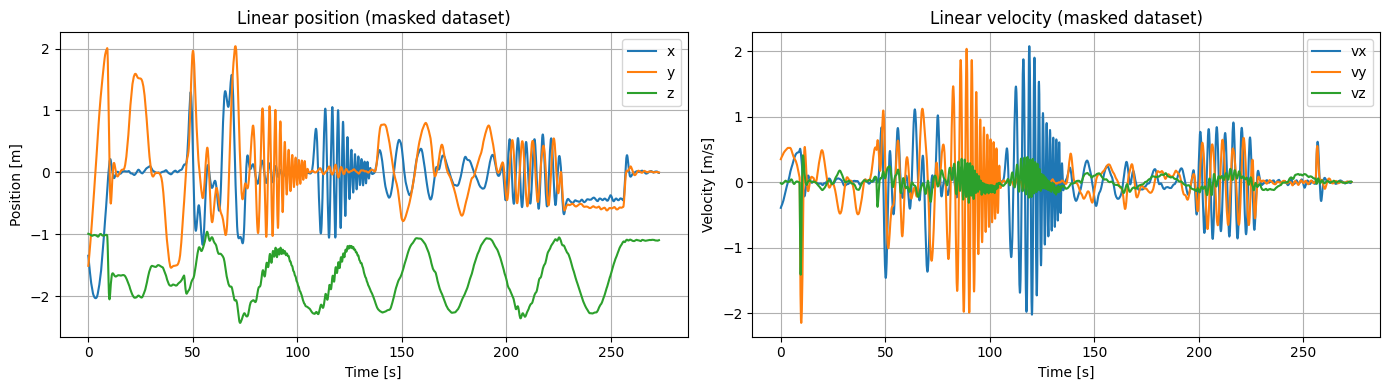

Dataset loaded from: dataset\dataset_masked.csv
Total samples: 13652
Train pairs: 10559, Val pairs: 2640
Test segments: [150, 150, 150]


In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Use masked dataset
DATASET_PATH = os.path.join("dataset", "dataset.csv")
dataset_df = pd.read_csv(DATASET_PATH)
dataset_np = dataset_df.to_numpy(dtype=np.float32)

# Convert cmd thrust to actual thrust in Newtons
dataset_np = px4_pwm_to_thrust(dataset_np)

# Global normalization statistics from masked dataset
mean, std = get_mean_and_std(dataset_np)

# Split into train/val pool and fixed test windows
dt_candidates = dataset_np[:, 1]
dt_nominal = float(np.median(dt_candidates[dt_candidates > 0])) if np.any(dt_candidates > 0) else 0.2
data_test_segments, data_train_val = split_data(dataset_np, time_period=3, dt=dt_nominal, t0=25, t1=125, t2=220)

# Create pairs for train/val
pairs_curr, pairs_next, _ = create_and_shuffle_pairs(data_train_val)
split_idx = int(0.8 * len(pairs_curr))
split_idx = min(max(split_idx, 1), len(pairs_curr) - 1)

train_data_current, val_data_current = pairs_curr[:split_idx], pairs_curr[split_idx:]
train_data_next, val_data_next = pairs_next[:split_idx], pairs_next[split_idx:]

X_train, X_train_next, U_train, U_train_next, dt_train = configure_training_and_validation_data(train_data_current, train_data_next)
X_val, X_val_next, U_val, U_val_next, dt_val = configure_training_and_validation_data(val_data_current, val_data_next)

# Keep only the 12-state used by physics/loss: [pos(3), euler(3), vel(3), ang_vel(3)]
X_train_phys = X_train[:, :12].float()
X_train_next_phys = X_train_next[:, :12].float()
X_val_phys = X_val[:, :12].float()
X_val_next_phys = X_val_next[:, :12].float()

U_train = U_train.float()
U_val = U_val.float()
dt_train = dt_train.float()
dt_val = dt_val.float()

# pick/define these if not already defined
mass = 2.0
inertia = torch.tensor([0.0217, 0.0217, 0.04])
g = 9.81

# make sure everything is torch tensors on the same device (CPU is fine)
delta_mu, delta_std = compute_real_delta_stats(
    X_train_phys,        # (B,12)
    U_train,             # (B,?)
    X_train_next_phys,   # (B,12)
    dt_train,            # (B,) or (B,1)
    mass=mass,
    inertia=inertia,
    g=g
)

print("delta_std:", delta_std)

# Quick visualization of masked data
time = dataset_np[:, 0]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(time, dataset_np[:, 2], label="x")
ax[0].plot(time, dataset_np[:, 3], label="y")
ax[0].plot(time, dataset_np[:, 4], label="z")
ax[0].set_title("Linear position (masked dataset)")
ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Position [m]")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(time, dataset_np[:, 5], label="vx")
ax[1].plot(time, dataset_np[:, 6], label="vy")
ax[1].plot(time, dataset_np[:, 7], label="vz")
ax[1].set_title("Linear velocity (masked dataset)")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Velocity [m/s]")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Dataset loaded from: {DATASET_PATH}")
print(f"Total samples: {len(dataset_np)}")
print(f"Train pairs: {len(train_data_current)}, Val pairs: {len(val_data_current)}")
print(f"Test segments: {[seg.shape[0] for seg in data_test_segments]}")

**Step 5: Define Data-loss**

In [ ]:
import torch
import torch.nn as nn
# from a_System_dynamics.system_dynamics import system_dynamics

_mse_loss = nn.MSELoss()

def compute_new_pos_angles(delta_vw, X_curr, U_curr, dt, mass, inertia, g):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    # baseline physics derivative
    x_dot_phys = system_dynamics(X_curr, U_curr, mass, inertia=inertia, g=g)  # (B,12)

    # NN correction (delta_vw)
    # delta_vw = model(X_curr, U_curr)  # (B,6)

    delta_v = delta_vw[:, 0:3]  # (B,3) correction for linear velocities
    delta_w = delta_vw[:, 3:6]  # (B,3) correction for angular velocities

    x_next_base = X_curr + x_dot_phys * dt  # Next state

    v_next = x_next_base[:, 6:9] + delta_v  # New predicted next linear velocity with correction
    w_next = x_next_base[:, 9:12] + delta_w  # New predicted next angular velocity with correction

    # 3) integrate pose using corrected velocities/angular velocities
    roll  = X_curr[:, 3]
    pitch = X_curr[:, 4]
    yaw   = X_curr[:, 5]

    vx, vy, vz = v_next[:, 0], v_next[:, 1], v_next[:, 2]
    w_roll, w_pitch, w_yaw = w_next[:, 0], w_next[:, 1], w_next[:, 2]

    # position derivatives in world frame
    x_dot = vx
    y_dot = vy
    z_dot = vz

    # Euler angle rates (same formulas you used) using corrected angular rates
    # NOTE: this has singularities at cos(pitch)=0 (pitch = +- 90 deg)
    roll_dot  = w_roll + torch.sin(roll) * torch.tan(pitch) * w_pitch + torch.cos(roll) * torch.tan(pitch) * w_yaw
    pitch_dot = torch.cos(roll) * w_pitch - torch.sin(roll) * w_yaw
    yaw_dot   = (torch.sin(roll) / torch.cos(pitch)) * w_pitch + (torch.cos(roll) / torch.cos(pitch)) * w_yaw

    pos_angles_dot = torch.stack([x_dot, y_dot, z_dot, roll_dot, pitch_dot, yaw_dot], dim=1)  # (B,6)
    pos_angles_next = X_curr[:, 0:6] + pos_angles_dot * dt                                    # (B,6) Integrate to get new position and angles

    # Assemble final corrected next state
    X_next = x_next_base.clone()
    X_next[:, 0:6] = pos_angles_next
    X_next[:, 6:9] = v_next
    X_next[:, 9:12] = w_next

    return X_next


def data_loss(model, X_curr, U_curr_NN, X_next, dt,
              mass=2.0, inertia=torch.tensor([0.0217, 0.0217, 0.04]), g=9.81,
              channel_weights=None, lambda_corr=0):
    if dt.ndim == 1:
        dt = dt.view(-1, 1)

    # baseline physics derivative
    # x_dot_phys = system_dynamics(X_curr, U_curr_NN, mass, inertia=inertia, g=g)  # (B,12)

    # x_next_base = X_curr + x_dot_phys * dt  # Next state from physics only

    # target_delta_state = X_next - x_next_base  # What the NN should ideally learn to correct

    # Next state prediction using the NN correction in velocity space and integration (more physics-informed)
    
    delta_vw = model(X_curr, U_curr_NN)  # (B,6)
    
    X_next_NN = compute_new_pos_angles(delta_vw, X_curr, U_curr_NN, dt, mass, inertia, g)  # (B,12)

    # channel-wise MSE, predicted corrected (to keep your weighting approach)
    per_channel_losses = torch.mean((X_next_NN[:, 6:12] - X_next[:, 6:12]) ** 2, dim=0)  # (12,)

    if channel_weights is None:
        cw = torch.ones(6, device=X_curr.device, dtype=X_curr.dtype)
    else:
        cw = channel_weights.to(device=X_curr.device, dtype=X_curr.dtype)

    loss_data_corr = torch.sum(cw * per_channel_losses)

    loss_corr_reg = lambda_corr * torch.mean(delta_vw ** 2)  # Regularization to keep corrections small

    total_loss = loss_data_corr + loss_corr_reg
    return total_loss, {"loss_data_corr": loss_data_corr.detach(), "loss_corr_reg": loss_corr_reg.detach()}

**Step 6: Training and Validation**

Epoch 050/300 | train: 0.034059 | val: 0.034016
Epoch 100/300 | train: 0.022253 | val: 0.023246
Epoch 150/300 | train: 0.015752 | val: 0.017203
Epoch 200/300 | train: 0.011913 | val: 0.013556
Epoch 250/300 | train: 0.009270 | val: 0.011034
Epoch 300/300 | train: 0.007508 | val: 0.009354
Training complete.


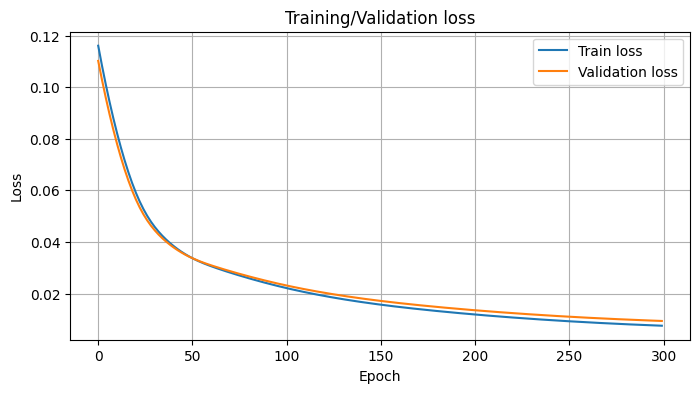

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Check for dead nodes in ReLU layers
dead_node_check = False
activation_class = nn.ELU

# ReLU, ReLU, Identity
model = ResidualBModel(
    hidden_layers_size=[128, 128, 128],
    # activation_fn=nn.ReLU, # ReLU works but 20% of nodes are dead at the end of training in layer 3
    activation_fn=nn.ELU, # ELU works best
    # activation_fn=nn.SELU,
    output_activation=nn.Identity,
).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# Add scheduler

scheduler_plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=300,
    threshold=1e-5,
    threshold_mode='abs',
    min_lr=1e-5 # Might be better with 5e-6 because of instability at ~20000-30000 epochs
)

scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max= 3500,      # decay over first ~1/3 training
    eta_min=1e-4
)

if dead_node_check == True:

    relu_stats = {}
    dead_neuron_stats = {}

    def relu_hook(name):
        def hook(module, input, output):
            if not isinstance(output, torch.Tensor):
                return

            # Fraction of near-zero activations
            zero_frac = (output < 1e-6).float().mean().item()

            # Fraction of neurons inactive across entire batch
            if output.dim() > 1:
                dead_frac = (output < 1e-6).all(dim=0).float().mean().item()
            else:
                dead_frac = 0.0

            relu_stats[name] = zero_frac
            dead_neuron_stats[name] = dead_frac

        return hook

    hooks = []
    for name, layer in model.named_modules():
        if isinstance(layer, activation_class):
            hooks.append(layer.register_forward_hook(relu_hook(name)))

history_dead = {
    name: [] 
    for name, layer in model.named_modules() 
    if isinstance(layer, activation_class)
}


X_train_phys_d = X_train_phys.to(device)
X_train_next_phys_d = X_train_next_phys.to(device)
U_train_d = U_train.to(device)
dt_train_d = dt_train.to(device)

X_val_phys_d = X_val_phys.to(device)
X_val_next_phys_d = X_val_next_phys.to(device)
U_val_d = U_val.to(device)
dt_val_d = dt_val.to(device)

# [vx, vy, vz, wx, wy, wz]
channel_weights = torch.tensor(
    [1.0, 1.0, 1.0, 1, 1, 1],
    device=device,
    dtype=X_train_phys_d.dtype
)

# Regularization for correction term
lambda_corr = 0

# channel_weights = torch.ones(12, device=device)
num_epochs = 50000

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    train_loss, _ = data_loss(
        model=model,
        X_curr=X_train_phys_d,
        U_curr_NN=U_train_d,
        X_next=X_train_next_phys_d,
        dt=dt_train_d,
        channel_weights=channel_weights,
    )
    train_loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss, _ = data_loss(
            model=model,
            X_curr=X_val_phys_d,
            U_curr_NN=U_val_d,
            X_next=X_val_next_phys_d,
            dt=dt_val_d,
            channel_weights=channel_weights,
        )

    if optimizer.param_groups[0]['lr'] > 1e-4:
        scheduler_cosine.step()
    else:
        scheduler_plateau.step(val_loss)  # adaptive decay after LR floor

    train_losses.append(float(train_loss.item()))
    val_losses.append(float(val_loss.item()))

    if (epoch + 1) % 50 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:03d}/{num_epochs} | train: {train_losses[-1]:.6f} | val: {val_losses[-1]:.6f} | lr: {lr:.2e}")

    if dead_node_check == True:
        if (epoch + 1) % 100 == 0:
            print("ReLU zero fractions:")
            for name, frac in relu_stats.items():
                print(f"  {name}: {frac:.3f}")
            for name in dead_neuron_stats:
                if name not in history_dead:
                    history_dead[name] = []
                history_dead[name].append(dead_neuron_stats[name])

print("Training complete.")


if dead_node_check == True:
    for h in hooks:
        h.remove()

    print("\nFinal dead neuron averages:")
    for name, values in history_dead.items():
        avg = sum(values) / len(values)
        print(f"{name}: {avg:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training/Validation loss")
plt.grid(True)
plt.legend()
plt.show()

trained_model = model

**Step 7: Test trained model**

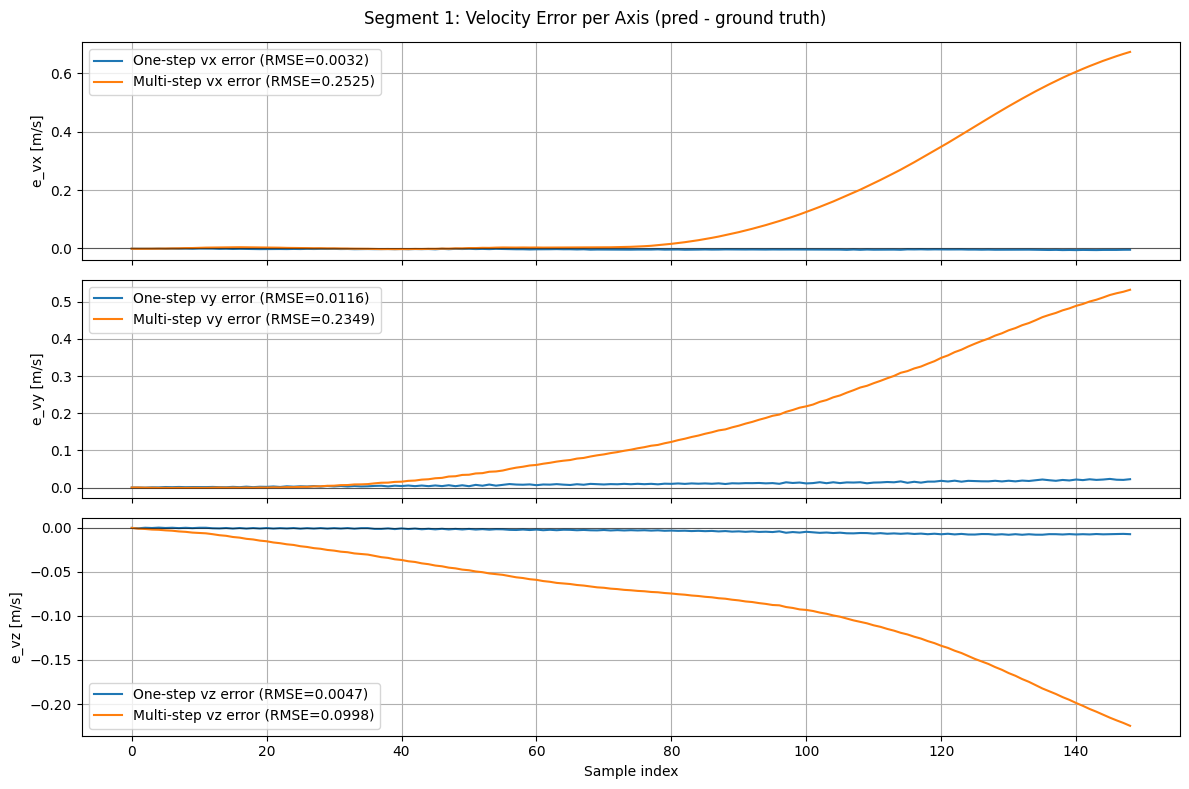

Segment 1 velocity RMSE | one-step [vx, vy, vz]=[0.003163, 0.011634, 0.004685] | multi-step [vx, vy, vz]=[0.252516, 0.234919, 0.099833]


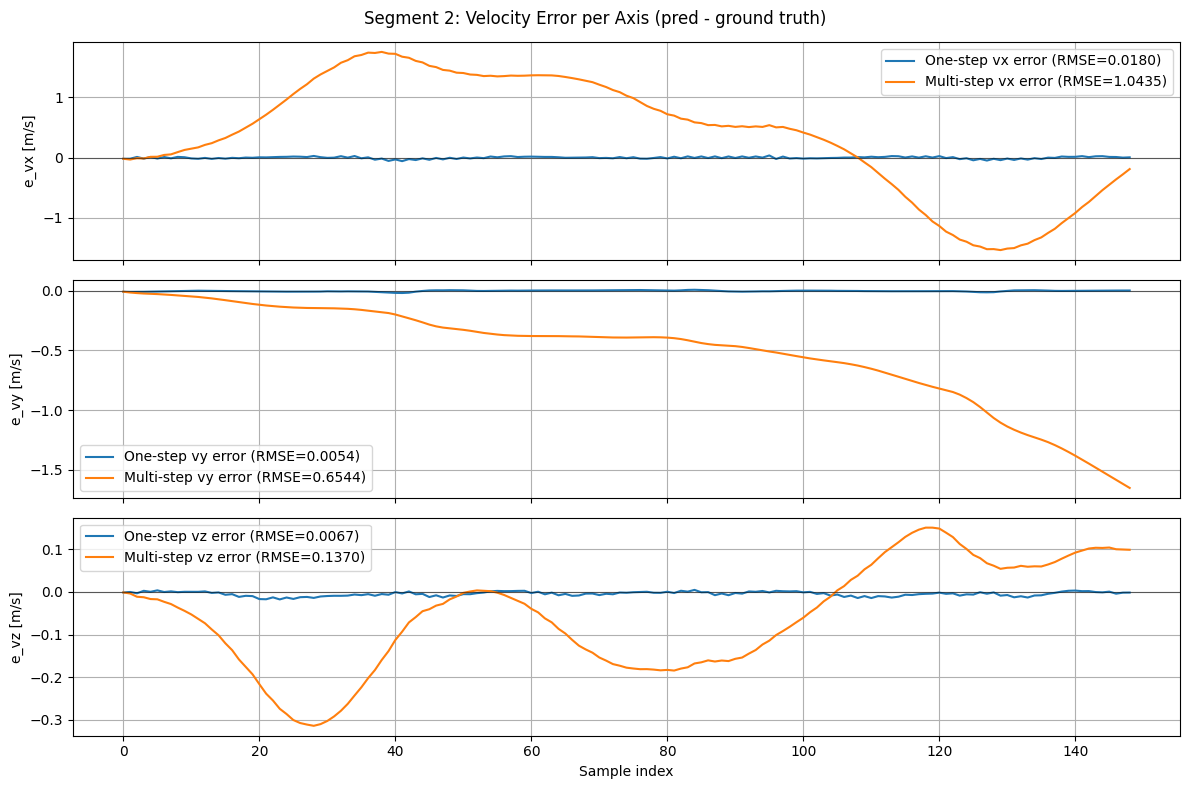

Segment 2 velocity RMSE | one-step [vx, vy, vz]=[0.017972, 0.005436, 0.006737] | multi-step [vx, vy, vz]=[1.043490, 0.654430, 0.136994]


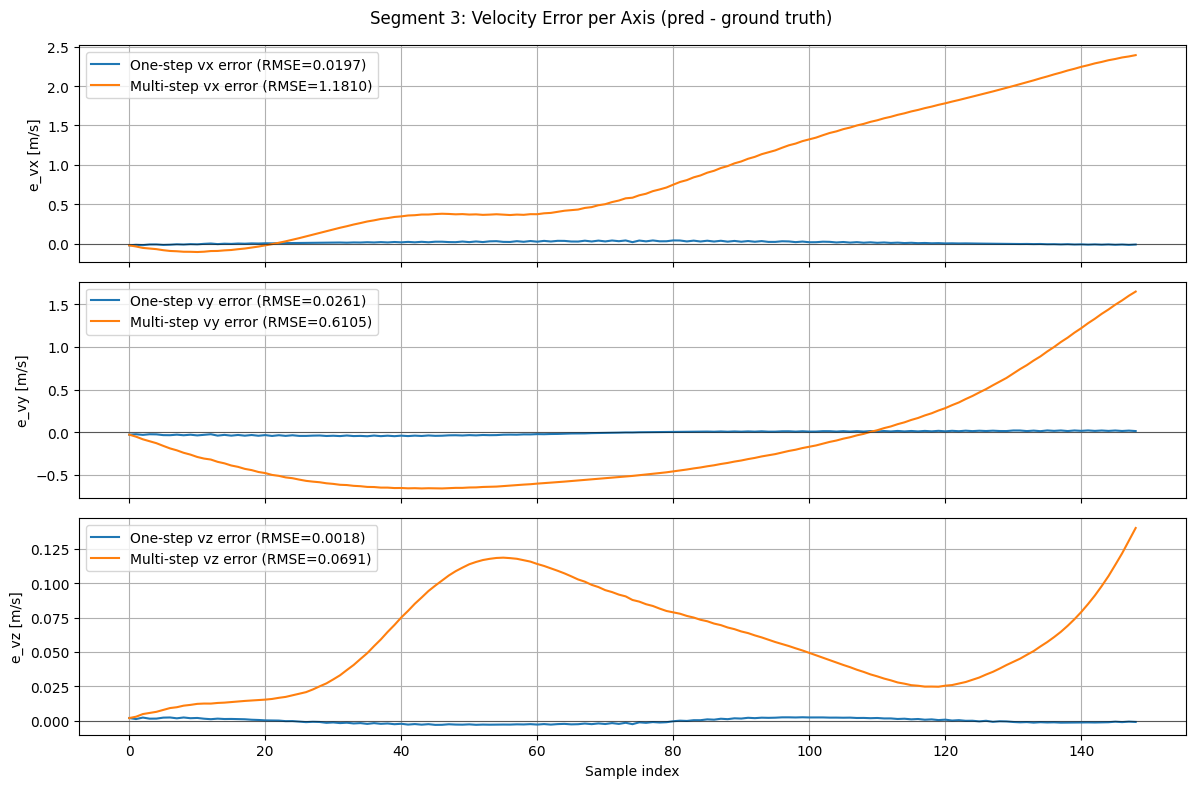

Segment 3 velocity RMSE | one-step [vx, vy, vz]=[0.019716, 0.026118, 0.001801] | multi-step [vx, vy, vz]=[1.181022, 0.610544, 0.069082]


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

STATE_NAMES = ["x","y","z","roll","pitch","yaw","vx","vy","vz","w_roll","w_pitch","w_yaw"]

@torch.no_grad()
def one_step_predictions(model, X_curr, U_curr, dt_curr, mass, inertia, g):
    """
    X_curr: (N-1,12)
    U_curr: (N-1,4)
    dt_curr: (N-1,1) or (N-1,)
    returns:
      X_next_phys: (N-1,12)
      X_next_corr: (N-1,12)
    """
    if dt_curr.ndim == 1:
        dt_curr = dt_curr.view(-1, 1)

    # physics-only
    xdot = system_dynamics(X_curr, U_curr, mass=mass, inertia=inertia, g=g)  # (N-1,12)
    X_next_phys = X_curr + xdot * dt_curr

    # corrected
    delta_vw = model(X_curr, U_curr)  # (N-1,6)
    X_next_corr = compute_new_pos_angles(delta_vw, X_curr, U_curr, dt_curr, mass, inertia, g)

    return X_next_phys, X_next_corr

def plot_two_column_next_state(t_next, X_next_gt, X_next_phys, X_next_corr, title):
    """
    t_next: (N-1,)
    X_next_*: (N-1,12)
    """
    n_states = 12
    fig, axes = plt.subplots(n_states, 2, figsize=(16, 2.2 * n_states), sharex=True)

    for i in range(n_states):
        axL = axes[i, 0]
        axL.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth (next)")
        axL.plot(t_next, X_next_phys[:, i], "C0--", lw=1.6, label="physics (1-step)")
        axL.set_ylabel(STATE_NAMES[i])
        axL.grid(True, alpha=0.3)
        if i == 0:
            axL.set_title("Physics (1-step) vs Ground Truth")
        if i == n_states - 1:
            axL.set_xlabel("time [s] (next sample)")

        axR = axes[i, 1]
        axR.plot(t_next, X_next_gt[:, i], "k-", lw=2, label="ground truth (next)")
        axR.plot(t_next, X_next_corr[:, i], "C1--", lw=1.6, label="physics + NN (1-step)")
        axR.grid(True, alpha=0.3)
        if i == 0:
            axR.set_title("Corrected (1-step) vs Ground Truth")
        if i == n_states - 1:
            axR.set_xlabel("time [s] (next sample)")

    handlesL, labelsL = axes[0, 0].get_legend_handles_labels()
    handlesR, labelsR = axes[0, 1].get_legend_handles_labels()
    fig.legend(handlesL + handlesR, labelsL + labelsR, loc="upper left", ncol=4, frameon=True)

    fig.suptitle(title, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

# ---------- run on your test segments ----------
mass = 2.0
inertia = torch.tensor([0.0217, 0.0217, 0.04], dtype=torch.float32, device=device)
g = 9.81

model = trained_model.to(device)
model.eval()

for seg_i, seg in enumerate(data_test_segments):
    # seg: (N, dataset_cols)
    states_np, controls_np, dt_np = configure_data(seg)  # states_np: (N,18), controls_np: (N,4), dt_np: (N,1)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)  # (N,12)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)        # (N,4)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device) # (N,)

    # Build 1-step pairs inside the segment
    X_curr = X[:-1, :]
    X_next_gt = X[1:, :]

    U_curr = U[:-1, :]

    # dt that takes you from curr -> next (dt[0] is often 0 due to diff; so use dt[1:])
    dt_curr = dt[1:]  # length N-1

    # time axis: next sample times
    t_next = seg[1:, 0]

    X_next_phys, X_next_corr = one_step_predictions(
        model=model,
        X_curr=X_curr,
        U_curr=U_curr,
        dt_curr=dt_curr,
        mass=mass,
        inertia=inertia,
        g=g
    )

    plot_two_column_next_state(
        t_next=t_next,
        X_next_gt=X_next_gt.detach().cpu().numpy(),
        X_next_phys=X_next_phys.detach().cpu().numpy(),
        X_next_corr=X_next_corr.detach().cpu().numpy(),
        title=f"One-step test | segment {seg_i} | t ∈ [{float(seg[0,0]):.2f}, {float(seg[-1,0]):.2f}] s"
    )

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

STATE_NAMES = ["x","y","z","roll","pitch","yaw","vx","vy","vz","w_roll","w_pitch","w_yaw"]

def plot_errors_vs_zero(t_next, err_phys, err_corr, title):
    """
    t_next: (N-1,)
    err_*:  (N-1,12)
    """
    n_states = 12
    fig, axes = plt.subplots(n_states, 1, figsize=(14, 2.0 * n_states), sharex=True)

    for i in range(n_states):
        ax = axes[i]
        ax.axhline(0.0, color="k", lw=1.5, label="ground truth = 0" if i == 0 else None)
        # ax.plot(t_next, err_phys[:, i], "C0--", lw=1.4, label="physics error" if i == 0 else None)
        ax.plot(t_next, err_corr[:, i], "C1--", lw=1.4, label="physics+NN error" if i == 0 else None)
        ax.set_ylabel(STATE_NAMES[i])
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("time [s] (next sample)")
    axes[0].set_title("One-step prediction error (prediction − ground truth)")

    # single legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper left", ncol=3, frameon=True)

    fig.suptitle(title, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

# ---- call this right after you compute X_next_phys, X_next_corr, X_next_gt in your one-step loop ----
# Example integration with the loop from the previous message:

for seg_i, seg in enumerate(data_test_segments):
    states_np, controls_np, dt_np = configure_data(seg)

    X = torch.tensor(states_np[:, :12], dtype=torch.float32, device=device)
    U = torch.tensor(controls_np, dtype=torch.float32, device=device)
    dt = torch.tensor(dt_np.squeeze(-1), dtype=torch.float32, device=device)

    X_curr = X[:-1, :]
    X_next_gt = X[1:, :]
    U_curr = U[:-1, :]
    dt_curr = dt[1:]              # curr -> next
    t_next = seg[1:, 0]           # next-sample times

    with torch.no_grad():
        X_next_phys, X_next_corr = one_step_predictions(
            model=trained_model,
            X_curr=X_curr,
            U_curr=U_curr,
            dt_curr=dt_curr,
            mass=mass,
            inertia=inertia,
            g=g
        )

    err_phys = (X_next_phys - X_next_gt).detach().cpu().numpy()
    err_corr = (X_next_corr - X_next_gt).detach().cpu().numpy()

    plot_errors_vs_zero(
        t_next=t_next,
        err_phys=err_phys,
        err_corr=err_corr,
        title=f"Error vs 0 | one-step | segment {seg_i}"
    )

**Step 8: Plot position error in 3D (Ground truth vs onestep vs multistep)**